In [1]:
library(ape)
library(ggtree)
library(ggplot2)
library(patchwork)
library(treeio)
library(phytools)
# set input and output paths

indir <- "../../results/coalescent_astral/astral4_nt"
outdir <- file.path(indir, "tree_plots")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

# color tips by biological lineage / comparison group
lineage_df <- data.frame(
    label = c("Bg", "Ee", "Bb", "Pk", "Ip"),
    lineage = c(
        "South American electric fishes",
        "South American electric fishes",
        "African weakly electric fishes",
        "African weakly electric fishes",
        "Ictaluridae outgroup"
    )
)

lineage_palette <- c(
    "South American electric fishes" = "#1b9e77",
    "African weakly electric fishes" = "#d95f02",
    "Ictaluridae outgroup" = "#7570b3"
)

lineage_shapes <- c(
    "South American electric fishes" = 21,
    "African weakly electric fishes" = 22,
    "Ictaluridae outgroup" = 24
)

ggtree v4.0.5 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan, Tommy Tsan-Yuk Lam.
ggtree: an R package for visualization and annotation of phylogenetic
trees with their covariates and other associated data. Methods in
Ecology and Evolution. 2017, 8(1):28-36. doi:10.1111/2041-210X.12628


Attaching package: ‘ggtree’


The following object is masked from ‘package:ape’:

    rotate


treeio v1.34.0 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

LG Wang, TTY Lam, S Xu, Z Dai, L Zhou, T Feng, P Guo, CW Dunn, BR
Jones, T Bradley, H Zhu, Y Guan, Y Jiang, G Yu. treeio: an R package
for phylogenetic tree input and output with richly annotated and
associated data. Molecular Biology and Evolution. 2020, 37(2):599-603.
doi: 10.1093/molbev/msz240

Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:treeio’:

    read.newick




In [2]:
## function to root tree using outgroup and plot
plot_tree <- function(tree_file, outfile_prefix, plot_title) {

    tree <- read.tree(tree_file)

    # used -o Ip, but ape still reads the tree as unrooted.
    if (is.rooted(tree)) {
        cat("Tree is already rooted\n")
    } else {
        cat("Tree is unrooted, rooting with Ip as outgroup...\n")
        cat("Unrooted tree:")
        print(tree)
        tree <- root(tree, outgroup = "Ip", resolve.root = FALSE)
    }
    tree <- ladderize(tree)

    cat("Rooted tree - with Ip:
")
    print(tree)

    p <- ggtree(tree, layout = "rectangular", size = 0.9) %<+% lineage_df +
        geom_tippoint( aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1 ) +
        geom_tiplab( aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE ) +
        geom_label2( aes(subset = !isTip & !is.na(label) & label != "", label = label), hjust = -0.15, vjust = -0.35, size = 3, label.size = 0.2, fill = "white",  color = "gray25"  ) +
        scale_color_manual(values = lineage_palette, name = "Lineage / group") +
        scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
        ggtitle(plot_title) +
        theme_tree2() +
        theme( plot.title = element_text(hjust = 0.5, face = "bold", size = 14), legend.position = "right", legend.title = element_text(face = "bold") )

    pdf_file <- paste0(outfile_prefix, ".pdf")
    png_file <- paste0(outfile_prefix, ".png")

    ggsave(pdf_file, plot = p, width = 8, height = 5)
    ggsave(png_file, plot = p, width = 8, height = 5, dpi = 300)

    cat("
")
    return(p)
}

#
plot_cophylo_colored <- function(outfile, type = c("pdf", "png"),title) {
    type <- match.arg(type)

    if (type == "pdf") {
        pdf(outfile, width = 13, height = 8)
    } else {
        png(outfile, width = 3900, height = 2400, res = 300)
    }

    par(mar = c(2, 2, 6, 10), xpd = NA)
    plot(co, fsize = 1.1, ftype = "i", link.type = "curved", link.lwd = 3, link.col = link_cols, pts = TRUE, pch = 21, mar = c(2, 2, 6, 10))
    mtext(title, side = 3, line = 3, cex = 1.4, font = 2)
    dev.off()
}

Tree is already rooted
Rooted tree - with Ip:

Phylogenetic tree with 5 tips and 4 internal nodes.

Tip labels:
  Ee, Bg, Bb, Pk, Ip
Node labels:
  , , 1, 1

Rooted; includes branch length(s).


Warning message in geom_label2(aes(subset = !isTip & !is.na(label) & label != "", :
“Ignoring unknown parameters: `label.size`”


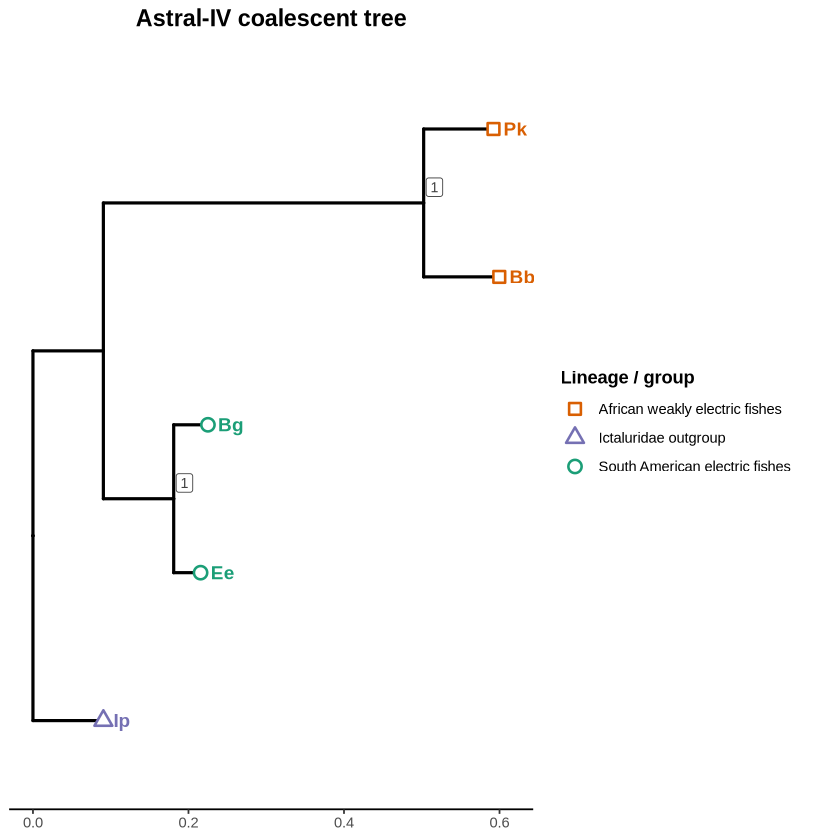

In [11]:
# plot tree
plot_tree(
	tree_file = file.path(indir, "astral4_species_tree_nt.tre"),
	outfile_prefix = file.path(outdir, "astral4_species_tree"),
	plot_title = "Astral-IV coalescent tree"
)

=> Comparing astral_rooted with mb_rooted.
Both trees have the same number of tips: 5.
Both trees have the same tip labels.
Both trees have the same number of nodes: 4.
Both trees are rooted.
Both trees are not ultrametric.
3 splits in common.



Warning message in dist.topo(astral_rooted, mb_rooted):
“Some trees were rooted: topological distances may be spurious.”


Robinson-Foulds distance: 0 Rotating nodes to optimize matching...
Done.


agg_record_861204331 
                   2

agg_record_861204331 
                   2

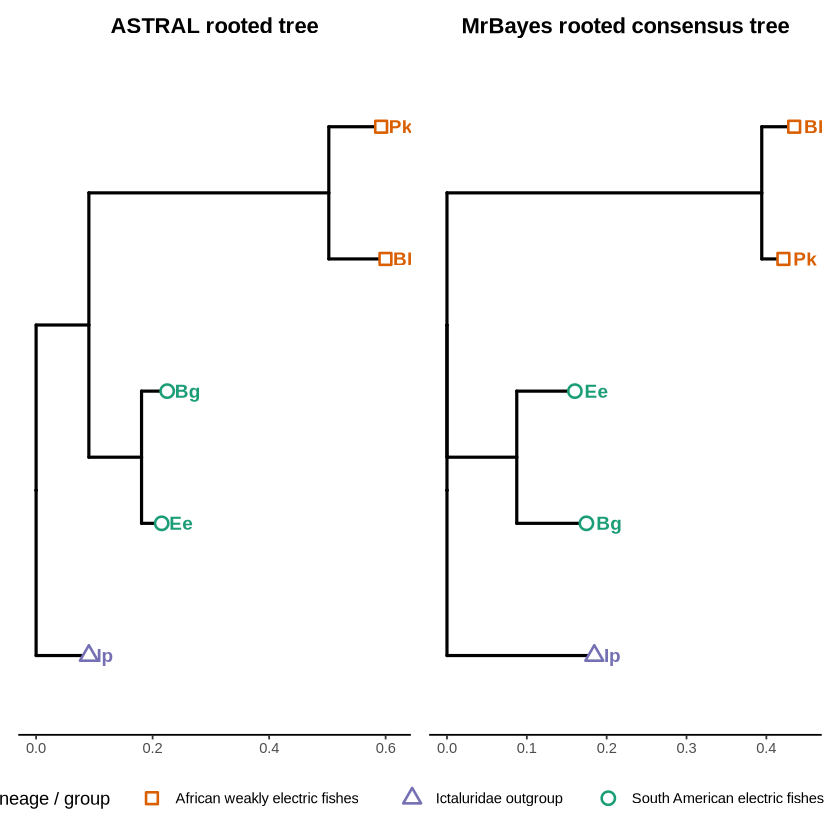

In [ ]:
## compare NT AStral and MrBayes trees

mb_file <- file.path("../../results/mrbayes/full_run/full_run_mrbayes.nex.con.tre")
astral_file <- file.path(indir, "astral4_species_tree_nt.tre")

compare_outdir <- file.path(outdir, "comparison_astral_mrbayes")
dir.create(compare_outdir, recursive = TRUE, showWarnings = FALSE)

astral_tree <- read.tree(astral_file)
mb_tree <- read.nexus(mb_file)

if (inherits(mb_tree, "multiPhylo")) {
    mb_tree <- mb_tree[[1]]
}

if (!setequal(astral_tree$tip.label, mb_tree$tip.label)) {
    stop("Tip labels do not match")
}

outgroup <- "Ip"

# Astral tree is already rooted.
if (is.rooted(astral_tree)){
    astral_rooted <- astral_tree
} else {
    cat("Astral tree is unrooted, rooting with Ip as outgroup...\n")
    astral_rooted <- root(astral_tree, outgroup = outgroup, resolve.root = TRUE)
}

mb_rooted <- root(mb_tree, outgroup = outgroup, resolve.root = TRUE)

astral_rooted <- ladderize(astral_rooted)
mb_rooted <- ladderize(mb_rooted)

compare_result <- capture.output(comparePhylo(astral_rooted, mb_rooted))
writeLines(compare_result)
writeLines(compare_result, file.path(compare_outdir, "comparePhylo_astral_nt_vs_mrbayes.txt"))

rf <- dist.topo(astral_rooted, mb_rooted)
cat("Robinson-Foulds distance:", rf, "")
writeLines( paste("Robinson-Foulds distance:", rf), file.path(compare_outdir, "rf_distance_astral_nt_vs_mrbayes.txt"))

assoc <- cbind(astral_rooted$tip.label, astral_rooted$tip.label)
link_cols <- lineage_palette[lineage_df$lineage[match(assoc[, 1], lineage_df$label)]]

co <- cophylo( astral_rooted, mb_rooted, assoc = assoc, rotate = TRUE)

plot_cophylo_colored(file.path(compare_outdir, "cophylo_astral_nt_vs_mrbayes.pdf"), type = "pdf", title = "Cophylo comparison of Astral-IV and MrBayes trees" )
plot_cophylo_colored(file.path(compare_outdir, "cophylo_astral_nt_vs_mrbayes.png"), type = "png",title ="Cophylo comparison of Astral-IV and MrBayes trees")

# Also save cleaner side-by-side ggtree plots.
p_iq <- ggtree(astral_rooted, size = 0.9) %<+% lineage_df +
    geom_tippoint(aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1) +
    geom_tiplab(aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE) +
    scale_color_manual(values = lineage_palette, name = "Lineage / group") +
    scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
    ggtitle("ASTRAL rooted tree") +
    theme_tree2() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))

p_mb <- ggtree(mb_rooted, size = 0.9) %<+% lineage_df +
    geom_tippoint(aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1) +
    geom_tiplab(aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE) +
    scale_color_manual(values = lineage_palette, name = "Lineage / group") +
    scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
    ggtitle("MrBayes rooted consensus tree") +
    theme_tree2() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))

side_by_side <- p_iq + p_mb + plot_layout(ncol = 2, guides = "collect") &
    theme(legend.position = "bottom")

ggsave( filename = file.path(compare_outdir, "astral_nt_mrbayes_side_by_side.pdf"), plot = side_by_side, width = 14, height = 6 )

ggsave( filename = file.path(compare_outdir, "astral_nt_mrbayes_side_by_side.png"), plot = side_by_side, width = 14, height = 6, dpi = 300)

side_by_side
